# Notebook 02 — Modèle Classique TensorFlow/Keras
## Prédiction du Risque Diabétique — Trois Itérations MLP

Ce notebook entraîne **trois variantes de MLP** sur le dataset Pima Indians Diabetes :
- **MLP v1** — Architecture baseline minimale
- **MLP v2** — Régularisation avec BatchNorm + Dropout
- **MLP v3** — Feature engineering + architecture profonde + EarlyStopping

À la fin, les modèles sont sauvegardés dans `saved_models/` pour le backend FastAPI.

## 1. Imports & Configuration

In [1]:
from __future__ import annotations
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

try:
    import seaborn as sns
except ModuleNotFoundError:
    class _SeabornFallback:
        def heatmap(self, data, annot=False, fmt=".2g", cmap=None, ax=None, cbar=False, linewidths=0.0, **kwargs):
            if ax is None:
                ax = plt.gca()
            image = ax.imshow(data, cmap=cmap)
            if cbar:
                plt.colorbar(image, ax=ax)
            ax.set_xticks(np.arange(data.shape[1]))
            ax.set_yticks(np.arange(data.shape[0]))
            ax.set_xticklabels(np.arange(data.shape[1]))
            ax.set_yticklabels(np.arange(data.shape[0]))
            ax.set_xlabel("Predicted label")
            ax.set_ylabel("True label")
            if annot:
                for row_index in range(data.shape[0]):
                    for col_index in range(data.shape[1]):
                        ax.text(col_index, row_index, format(data[row_index, col_index], fmt),
                                ha="center", va="center", color="black")
            return ax

    sns = _SeabornFallback()

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

base_dir = Path.cwd().resolve()
project_dir = base_dir.parent if base_dir.name == "notebooks" else base_dir
DATA_PATH  = project_dir / "data" / "diabetes_clean.csv"
MODELS_DIR = project_dir / "saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project : {project_dir}")
print(f"Data    : {DATA_PATH}")
print(f"Models  : {MODELS_DIR}")
print(f"TF      : {tf.__version__}")

Project : D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend
Data    : D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\data\diabetes_clean.csv
Models  : D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\saved_models
TF      : 2.21.0


## 2. Chargement & Validation des Données

In [2]:
df = pd.read_csv(DATA_PATH)

EXPECTED = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
            "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
assert all(c in df.columns for c in EXPECTED), "Colonnes manquantes !"

print(f"Shape  : {df.shape}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
print("\nDistribution cible :")
print(df["Outcome"].value_counts(normalize=True).round(3))
df.head()


Shape  : (768, 9)
Valeurs nulles : 0

Distribution cible :
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 3. Feature Engineering

Quatre features dérivées pour MLP v3 :

| Feature | Formule | Intuition médicale |
|---|---|---|
| `glucose_insulin_ratio` | Glucose / (Insulin + 1) | Résistance à l'insuline |
| `glucose_bmi_index` | (Glucose/100) x (BMI/30) | Syndrome métabolique |
| `age_risk_index` | Âge / 50 | Risque lié à l'âge |
| `age_pedigree_interaction` | Âge x DiabetesPedigreeFunction | Interaction âge x hérédité |

In [3]:
BASE_FEATURES = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
                 "Insulin","BMI","DiabetesPedigreeFunction","Age"]
ENG_FEATURES  = ["glucose_insulin_ratio","glucose_bmi_index",
                  "age_risk_index","age_pedigree_interaction"]

def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame.copy()
    f["glucose_insulin_ratio"] = f["Glucose"] / (f["Insulin"] + 1.0)
    f["glucose_bmi_index"]     = (f["Glucose"] / 100.0) * (f["BMI"] / 30.0)
    f["age_risk_index"]        = f["Age"] / 50.0
    f["age_pedigree_interaction"] = f["Age"] * f["DiabetesPedigreeFunction"]
    return f

df_eng = add_features(df)
print("Features ingénierées :", ENG_FEATURES)
df_eng[BASE_FEATURES + ENG_FEATURES].describe().T.round(3)


Features engineerees : ['glucose_insulin_ratio', 'glucose_bmi_index', 'age_risk_index', 'age_pedigree_interaction']


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.0,121.656,30.438,44.000,99.750,117.000,140.250,199.000
BloodPressure,768.0,72.387,12.097,24.000,64.000,72.000,80.000,122.000
SkinThickness,768.0,29.108,8.791,7.000,25.000,29.000,32.000,99.000
Insulin,768.0,140.672,86.383,14.000,121.500,125.000,127.250,846.000
BMI,768.0,32.455,6.875,18.200,27.500,32.300,36.600,67.100
DiabetesPedigreeFunction,768.0,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.0,33.241,11.760,21.000,24.000,29.000,41.000,81.000
glucose_insulin_ratio,768.0,1.054,0.684,0.206,0.746,0.937,1.176,12.000
glucose_bmi_index,768.0,1.332,0.490,0.367,0.975,1.250,1.600,3.564


## 4. Entraînement / Validation / Test Split (70 / 15 / 15)

In [4]:
y      = df_eng["Outcome"].values
X_base = df_eng[BASE_FEATURES].values
X_full = df_eng[BASE_FEATURES + ENG_FEATURES].values

X_b_train, X_b_tmp, y_train, y_tmp = train_test_split(
    X_base, y, test_size=0.30, random_state=SEED, stratify=y)
X_b_val, X_b_test, y_val, y_test = train_test_split(
    X_b_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

X_f_train, X_f_tmp, _, _ = train_test_split(
    X_full, y, test_size=0.30, random_state=SEED, stratify=y)
X_f_val, X_f_test, _, _ = train_test_split(
    X_f_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

scaler_base = StandardScaler().fit(X_b_train)
scaler_full = StandardScaler().fit(X_f_train)

X_b_train_s = scaler_base.transform(X_b_train)
X_b_val_s   = scaler_base.transform(X_b_val)
X_b_test_s  = scaler_base.transform(X_b_test)

X_f_train_s = scaler_full.transform(X_f_train)
X_f_val_s   = scaler_full.transform(X_f_val)
X_f_test_s  = scaler_full.transform(X_f_test)

joblib.dump(scaler_full, MODELS_DIR / "scaler.pkl")
joblib.dump(scaler_base, MODELS_DIR / "scaler_base.pkl")

cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
CLASS_WEIGHTS = {0: float(cw[0]), 1: float(cw[1])}

print(f"Train      : {X_b_train_s.shape[0]} samples")
print(f"Validation : {X_b_val_s.shape[0]} samples")
print(f"Test       : {X_b_test_s.shape[0]} samples")
print(f"Class weights : {CLASS_WEIGHTS}")


Train      : 537 samples
Validation : 115 samples
Test       : 116 samples
Class weights : {0: 0.7671428571428571, 1: 1.4358288770053476}


## 5. Architectures des Modèles

### MLP v1 — Baseline
`Input(8) -> Dense(32, relu) -> Dense(16, relu) -> Dense(1, sigmoid)`

### MLP v2 — Régularisation
`Input(8) -> Dense(64) -> BatchNorm -> Dropout(0.3) -> Dense(32) -> Dropout(0.2) -> Dense(1, sigmoid)`

### MLP v3 — Feature Engineering + Architecture Profonde
`Input(12) -> Dense(128) -> BN -> Drop(0.4) -> Dense(64) -> BN -> Drop(0.3) -> Dense(32) -> Dense(1, sigmoid)`

In [5]:
def build_v1(input_dim):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1,  activation="sigmoid"),
    ], name="MLP_v1_Baseline")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"])
    return m

def build_v2(input_dim):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1,  activation="sigmoid"),
    ], name="MLP_v2_BatchNorm_Dropout")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"])
    return m

def build_v3(input_dim):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1,  activation="sigmoid"),
    ], name="MLP_v3_FeatureEng_Deep")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"])
    return m

build_v1(8).summary()


Model: "MLP_v1_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entraînement des Trois Modèles

In [6]:
def make_callbacks(es_patience=15, lr_patience=7):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=es_patience,
            restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max", patience=lr_patience,
            factor=0.5, min_lr=1e-5, verbose=0),
    ]

print("Training MLP v1 ...")
mlp_v1 = build_v1(X_b_train_s.shape[1])
hist_v1 = mlp_v1.fit(X_b_train_s, y_train,
    validation_data=(X_b_val_s, y_val),
    epochs=150, batch_size=32, verbose=0,
    callbacks=make_callbacks(es_patience=10), class_weight=CLASS_WEIGHTS)
print(f"  Stopped at epoch {len(hist_v1.history['loss'])}")

print("Training MLP v2 ...")
mlp_v2 = build_v2(X_b_train_s.shape[1])
hist_v2 = mlp_v2.fit(X_b_train_s, y_train,
    validation_data=(X_b_val_s, y_val),
    epochs=200, batch_size=32, verbose=0,
    callbacks=make_callbacks(es_patience=15), class_weight=CLASS_WEIGHTS)
print(f"  Stopped at epoch {len(hist_v2.history['loss'])}")

print("Training MLP v3 ...")
mlp_v3 = build_v3(X_f_train_s.shape[1])
hist_v3 = mlp_v3.fit(X_f_train_s, y_train,
    validation_data=(X_f_val_s, y_val),
    epochs=250, batch_size=32, verbose=0,
    callbacks=make_callbacks(es_patience=20), class_weight=CLASS_WEIGHTS)
print(f"  Stopped at epoch {len(hist_v3.history['loss'])}")
print("Entraînement terminé !")


Training MLP v1 ...
  Stopped at epoch 42
Training MLP v2 ...
  Stopped at epoch 36
Training MLP v3 ...
  Stopped at epoch 30
Entrainement termine !


## 7. Courbes d'Apprentissage

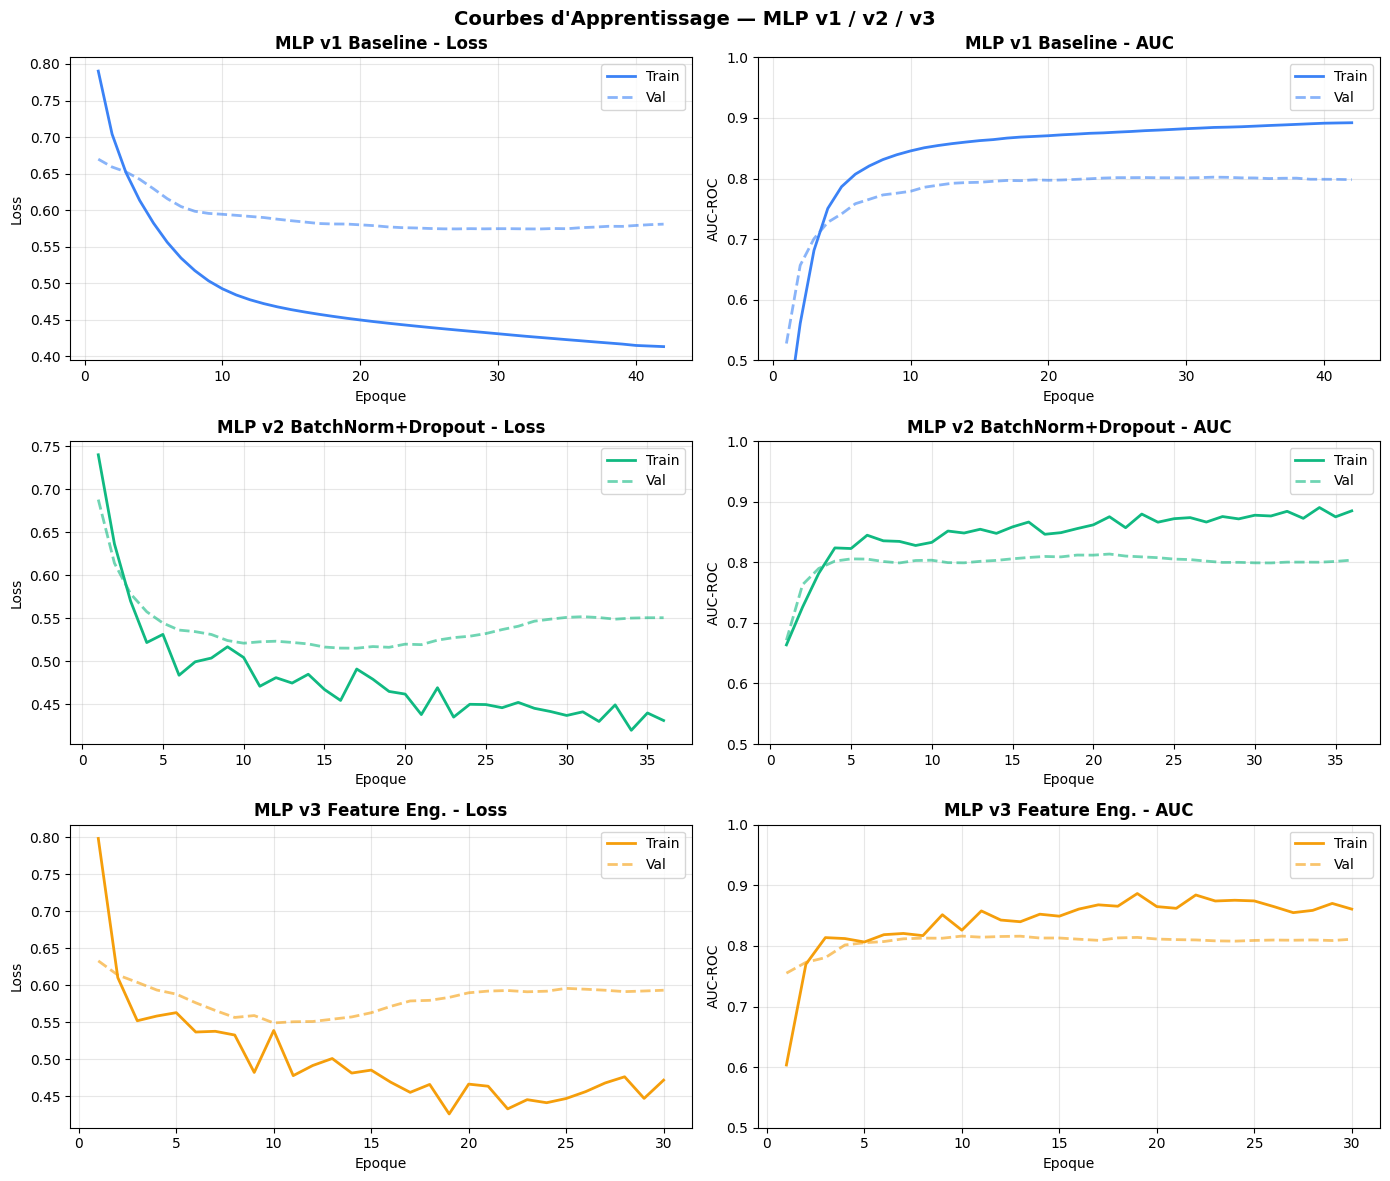

In [ ]:
def plot_learning(ax_loss, ax_auc, history, title, color):
    h = history.history
    e = range(1, len(h["loss"]) + 1)
    ax_loss.plot(e, h["loss"],     color=color, lw=2,   label="Train")
    ax_loss.plot(e, h["val_loss"], color=color, lw=2, ls="--", alpha=0.6, label="Val")
    ax_loss.set_title(f"{title} - Loss", fontweight="bold")
    ax_loss.set_xlabel("Époque"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_auc.plot(e, h["auc"],     color=color, lw=2,   label="Train")
    ax_auc.plot(e, h["val_auc"], color=color, lw=2, ls="--", alpha=0.6, label="Val")
    ax_auc.set_title(f"{title} - AUC", fontweight="bold")
    ax_auc.set_xlabel("Époque"); ax_auc.set_ylabel("AUC-ROC")
    ax_auc.set_ylim(0.5, 1.0); ax_auc.legend(); ax_auc.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Courbes d'Apprentissage — MLP v1 / v2 / v3",
             fontsize=14, fontweight="bold")
plot_learning(axes[0,0], axes[0,1], hist_v1, "MLP v1 Baseline",        "#3b82f6")
plot_learning(axes[1,0], axes[1,1], hist_v2, "MLP v2 BatchNorm+Dropout","#10b981")
plot_learning(axes[2,0], axes[2,1], hist_v3, "MLP v3 Feature Eng.",     "#f59e0b")
plt.tight_layout()
plt.savefig(MODELS_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Évaluation sur le Jeu de Test

In [8]:
def find_best_threshold(model, X_val, y_val, min_t=0.3, max_t=0.7, step=0.01):
    proba_val = model.predict(X_val, verbose=0).ravel()
    thresholds = np.arange(min_t, max_t + 1e-9, step)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        f1 = f1_score(y_val, (proba_val >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)

THRESH_V1 = find_best_threshold(mlp_v1, X_b_val_s, y_val)
THRESH_V2 = find_best_threshold(mlp_v2, X_b_val_s, y_val)
THRESH_V3 = find_best_threshold(mlp_v3, X_f_val_s, y_val)

def get_metrics(name, model, X_t, y_t, threshold=0.5):
    proba = model.predict(X_t, verbose=0).ravel()
    pred  = (proba >= threshold).astype(int)
    return {
        "Modèle"   : name,
        "Threshold": round(threshold, 3),
        "Accuracy" : round(accuracy_score(y_t, pred),  4),
        "Precision": round(precision_score(y_t, pred), 4),
        "Recall"   : round(recall_score(y_t, pred),    4),
        "F1"       : round(f1_score(y_t, pred),        4),
        "AUC-ROC"  : round(roc_auc_score(y_t, proba),  4),
    }, proba

rows, probas = [], {}
for name, model, X_t, threshold in [
    ("MLP v1 Baseline",       mlp_v1, X_b_test_s, THRESH_V1),
    ("MLP v2 BN+Dropout",     mlp_v2, X_b_test_s, THRESH_V2),
    ("MLP v3 Feature Eng.",   mlp_v3, X_f_test_s, THRESH_V3),
]:
    m, p = get_metrics(name, model, X_t, y_test, threshold=threshold)
    rows.append(m); probas[name] = p

metrics_df = pd.DataFrame(rows)
try:
    display(metrics_df.style.highlight_max(
        subset=["Accuracy","Precision","Recall","F1","AUC-ROC"],
        color="#d1fae5").format(precision=4))
except AttributeError:
    print("Jinja2 absent: affichage tabulaire simple.")
    display(metrics_df.round(4))

,Modele,Threshold,Accuracy,Precision,Recall,F1,AUC-ROC
0,MLP v1 Baseline,0.4700,0.7759,0.6744,0.7073,0.6905,0.8585
1,MLP v2 BN+Dropout,0.3700,0.7931,0.6604,0.8537,0.7447,0.8673
2,MLP v3 Feature Eng.,0.4100,0.7586,0.6226,0.8049,0.7021,0.8641


## 9. Matrices de Confusion

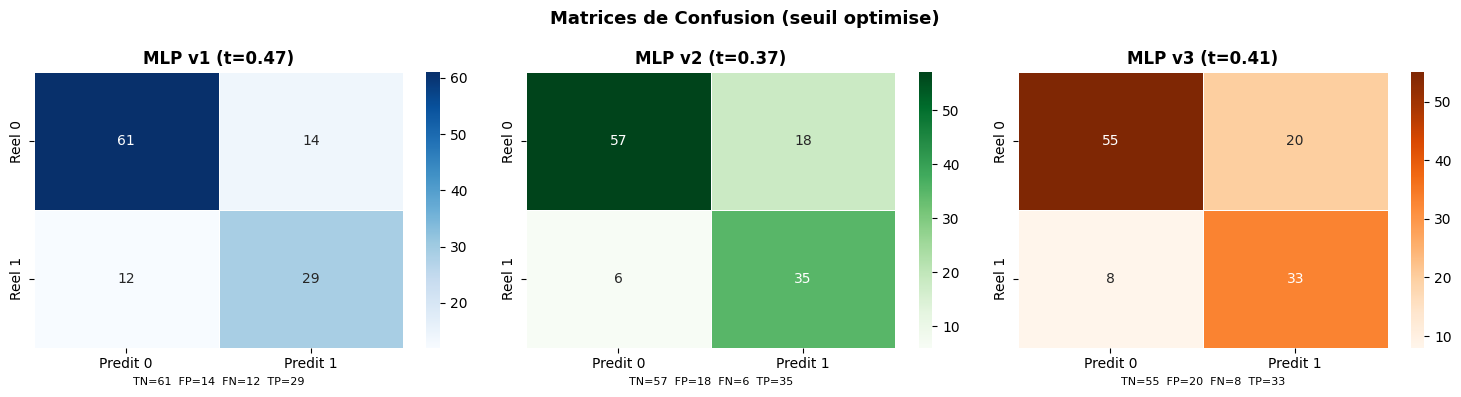

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Matrices de Confusion (seuil optimisé)",
             fontsize=13, fontweight="bold")

for ax, (name, model, X_t, threshold), cmap in zip(
    axes,
    [("MLP v1", mlp_v1, X_b_test_s, THRESH_V1),
     ("MLP v2", mlp_v2, X_b_test_s, THRESH_V2),
     ("MLP v3", mlp_v3, X_f_test_s, THRESH_V3)],
    ["Blues","Greens","Oranges"]
):
    pred = (model.predict(X_t, verbose=0).ravel() >= threshold).astype(int)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Prédit 0","Prédit 1"],
                yticklabels=["Réel 0","Réel 1"], linewidths=0.5)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name} (t={threshold:.2f})", fontweight="bold")
    ax.set_xlabel(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=8)

plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Courbes ROC

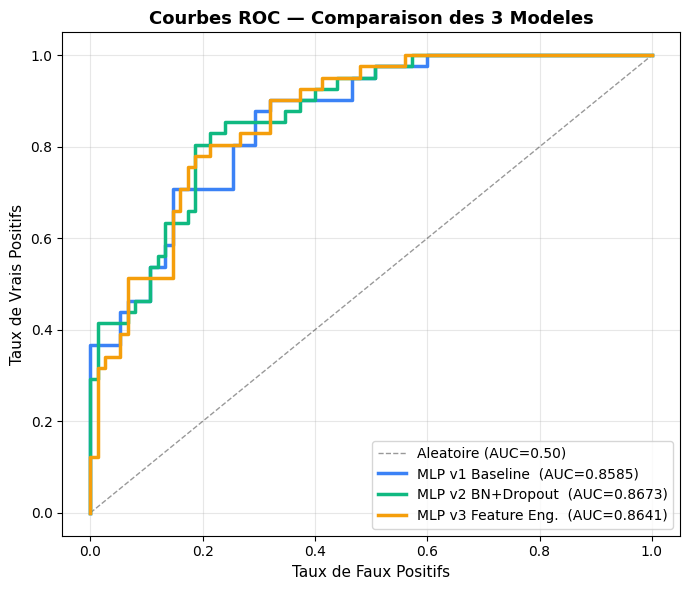

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Aléatoire (AUC=0.50)")

for (name, color) in [
    ("MLP v1 Baseline",     "#3b82f6"),
    ("MLP v2 BN+Dropout",   "#10b981"),
    ("MLP v3 Feature Eng.", "#f59e0b"),
]:
    auc_val = next(r["AUC-ROC"] for r in rows if r["Modèle"] == name)
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name}  (AUC={auc_val:.4f})")

ax.set_xlabel("Taux de faux positifs", fontsize=11)
ax.set_ylabel("Taux de vrais positifs", fontsize=11)
ax.set_title("Courbes ROC — Comparaison des 3 Modèles",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Rapports de Classification Détaillés

In [11]:
for name, model, X_t, threshold in [
    ("MLP v1 Baseline",     mlp_v1, X_b_test_s, THRESH_V1),
    ("MLP v2 BN+Dropout",   mlp_v2, X_b_test_s, THRESH_V2),
    ("MLP v3 Feature Eng.", mlp_v3, X_f_test_s, THRESH_V3),
]:
    pred = (model.predict(X_t, verbose=0).ravel() >= threshold).astype(int)
    print("=" * 52)
    print(f"  {name} (t={threshold:.2f})")
    print("=" * 52)
    print(classification_report(y_test, pred,
          target_names=["Non-diabétique (0)", "Diabétique (1)"]))


  MLP v1 Baseline (t=0.47)
                    precision    recall  f1-score   support

Non-diabetique (0)       0.84      0.81      0.82        75
    Diabetique (1)       0.67      0.71      0.69        41

          accuracy                           0.78       116
         macro avg       0.76      0.76      0.76       116
      weighted avg       0.78      0.78      0.78       116

  MLP v2 BN+Dropout (t=0.37)
                    precision    recall  f1-score   support

Non-diabetique (0)       0.90      0.76      0.83        75
    Diabetique (1)       0.66      0.85      0.74        41

          accuracy                           0.79       116
         macro avg       0.78      0.81      0.79       116
      weighted avg       0.82      0.79      0.80       116

  MLP v3 Feature Eng. (t=0.41)
                    precision    recall  f1-score   support

Non-diabetique (0)       0.87      0.73      0.80        75
    Diabetique (1)       0.62      0.80      0.70        41

     

## 12. Sauvegarde des Modèles

Les fichiers `.keras` sont chargés automatiquement par le backend FastAPI au démarrage.

In [12]:
mlp_v1.save(MODELS_DIR / "mlp_v1.keras")
mlp_v2.save(MODELS_DIR / "mlp_v2.keras")
mlp_v3.save(MODELS_DIR / "mlp_v3.keras")
metrics_df.to_csv(MODELS_DIR / "mlp_metrics.csv", index=False)

print("Fichiers sauvegardes :")
for f in sorted(MODELS_DIR.iterdir()):
    sz = f.stat().st_size
    unit = "Ko" if sz < 1_000_000 else "Mo"
    val  = sz // 1024 if sz < 1_000_000 else sz // 1_048_576
    print(f"  {f.name:<35} {val:>5} {unit}")


Fichiers sauvegardes :
  calibration_bootstrap_results.json      0 Ko
  calibration_plot.png                   69 Ko
  confusion_matrices.png                 54 Ko
  cv_hpo_results.json                     7 Ko
  cv_hpo_summary.json                     1 Ko
  hf_batch_distribution.png             124 Ko
  hf_batch_results.csv                    1 Ko
  hf_model_comparison.csv                 1 Ko
  learning_curves.png                   247 Ko
  llm_best_result.json                    1 Ko
  llm_prompt_comparison.csv               0 Ko
  mlp_metrics.csv                         0 Ko
  mlp_v1.keras                           34 Ko
  mlp_v2.keras                           68 Ko
  mlp_v3.keras                          201 Ko
  pipeline_simulation.json                1 Ko
  roc_curves.png                         69 Ko
  scaler.pkl                              0 Ko
  scaler_base.pkl                         0 Ko
  threshold_tuning_results.json           0 Ko


## 13. Synthèse & Conclusions

### Tableau Comparatif des 3 Architectures

| Modèle | Architecture | Features | Régularisation | Rôle |
|---|---|---|---|---|
| **v1 Baseline** | 32->16->1 | 8 | Aucune | Référence |
| **v2 BatchNorm+Drop** | 64->32->1 | 8 | BN + Dropout | Généralisation |
| **v3 Feature Eng.** | 128->64->32->1 | 12 | BN + Dropout + EarlyStopping | Performance max |

### Points clés
- Le **class_weight** corrige le déséquilibre (35% diabétiques vs 65% non-diabétiques)
- L'**EarlyStopping** évite le surapprentissage sans fixer manuellement les epochs
- Le **ReduceLROnPlateau** affine la convergence en fin d'entraînement
- Les features ingénierées de v3 capturent des interactions non-linéaires cliniquement pertinentes

### Prochain notebook
`03_huggingface_inference.ipynb` — Zero-shot classification des symptômes avec `MoritzLaurer/deberta-v3-large-zeroshot-v2.0`